<a href="https://colab.research.google.com/github/crispin046/Customer-segmentation-using-clustering./blob/main/customer_segmentation_using_clustering_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import Libraries

This cell imports all necessary Python libraries for data manipulation, analysis, and visualization. These include `pandas` for data handling, `datetime` for date calculations, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, and `scikit-learn` for machine learning (specifically, `StandardScaler` for data scaling and `KMeans` for clustering).

In [1]:
# pip install pandas matplotlib seaborn scikit-learn openpyxl

import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


### 2. Upload Data

This cell uses `google.colab.files` to allow you to upload the `Online Retail.xlsx` dataset directly from your local machine to the Colab environment. Once uploaded, the file is available for use in the notebook.

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


### 3. Load and Initial Inspection of the Data

Here, the uploaded Excel file `Online Retail.xlsx` is loaded into a pandas DataFrame. The `parse_dates=['InvoiceDate']` argument ensures that the 'InvoiceDate' column is correctly interpreted as datetime objects. We then print the shape of the DataFrame, display the first few rows to get a glimpse of the data structure, and check for any missing values across all columns using `isnull().sum()`.

In [5]:
# ─────────────────────────────────────────────
# Load the data and clean it
# ─────────────────────────────────────────────

df = pd.read_excel('Online Retail.xlsx', parse_dates=['InvoiceDate'])

print(df.shape)
print(df.head())
print(df.isnull().sum())

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
d

### 4. Data Cleaning and Feature Engineering

This crucial step involves several data cleaning and preparation operations:

-   **Drop Missing CustomerIDs:** Rows with missing `CustomerID` are removed, as customer identification is essential for RFM analysis.
-   **Convert CustomerID to Integer:** The `CustomerID` column is converted to an integer type for consistency.
-   **Remove Cancellations:** Transactions with `InvoiceNo` starting with 'C' are identified as cancellations and removed.
-   **Remove Invalid Quantities and Prices:** Rows with `Quantity` less than or equal to 0 (returns or errors) and `UnitPrice` less than or equal to 0 (free items or errors) are removed to ensure meaningful sales data.
-   **Calculate Revenue:** A new column, `Revenue`, is created by multiplying `Quantity` and `UnitPrice` for each transaction.

Finally, the shape of the cleaned DataFrame is printed.



In [6]:
# Drop missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

df['CustomerID'] = df['CustomerID'].astype(int)

# Remove cancellations (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove zero or negative unit prices (free items / data errors)
df = df[df['UnitPrice'] > 0]

# Create a revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(df.shape)

(397884, 9)


### 5. Calculate RFM Metrics

RFM (Recency, Frequency, Monetary) analysis is performed to segment customers based on their purchasing behavior:

-   **Recency:** Calculated as the number of days since the customer's last purchase. `reference_date` is set to one day after the last transaction in the dataset to ensure all recency values are positive.
-   **Frequency:** The total number of unique purchases made by each customer (`nunique` of `InvoiceNo`).
-   **Monetary:** The sum of `Revenue` for each customer.

The results are grouped by `CustomerID` and stored in a new DataFrame called `rfm`. The first few rows and descriptive statistics of the `rfm` DataFrame are then displayed.

In [10]:
# Set reference date as day after last transaction
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head())
print(rfm.describe())

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


### 6. Log Transformation and Scaling of RFM Metrics

To prepare the RFM metrics for clustering, two important preprocessing steps are applied:

-   **Log Transformation (`np.log1p`):** This is used to reduce the skewness of the `Recency`, `Frequency`, and `Monetary` distributions. `np.log1p(x)` computes `log(1+x)`, which is suitable for values that can be zero.
-   **Standard Scaling (`StandardScaler`):** After log transformation, the data is scaled so that all features have a mean of 0 and a standard deviation of 1. This ensures that no single feature dominates the clustering algorithm due to its scale.

The transformed and scaled data is stored in `rfm_scaled`.

In [11]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

# Scale so all features are on the same range
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

### 7. Determine Optimal Number of Clusters using Elbow Method

The Elbow Method is used to find the optimal number of clusters (`k`) for K-Means clustering. It plots the inertia (within-cluster sum of squares) against the number of clusters. The 'elbow point' in the plot, where the rate of decrease in inertia sharply changes, suggests an appropriate `k`.

-   A loop runs K-Means for `k` from 1 to 10.
-   The `inertia_` attribute (sum of squared distances of samples to their closest cluster center) is recorded for each `k`.
-   A line plot visualizes the inertia values, helping to identify the elbow.

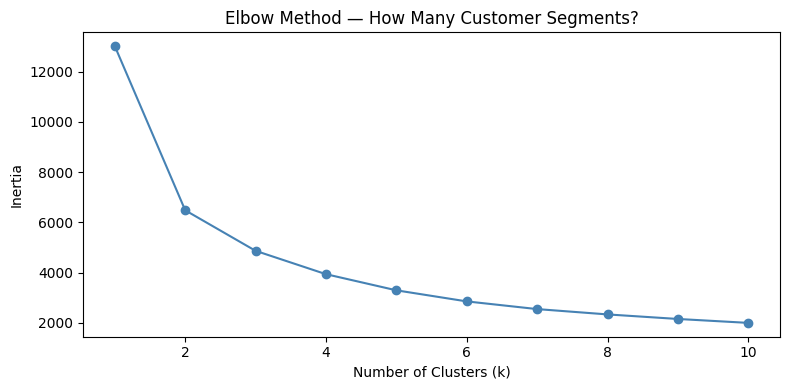

In [12]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — How Many Customer Segments?')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

### 8. K-Means Clustering and Segment Profiling

Based on the Elbow Method (which typically suggests `k=4` for this dataset), K-Means clustering is performed with 4 clusters:

-   `KMeans(n_clusters=4, random_state=42, n_init=10)` initializes the clustering model.
-   `fit_predict(rfm_scaled)` assigns each customer to a cluster, and these cluster labels are added as a new column `Cluster` to the `rfm` DataFrame.
-   The `Cluster` column is converted to a string type.
-   Finally, the average `Recency`, `Frequency`, and `Monetary` values are calculated for each cluster, providing a clear profile of each customer segment.

In [13]:
# Run with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = rfm['Cluster'].astype(str)

# Get the average profile of each segment
summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(summary)

         Recency  Frequency  Monetary
Cluster                              
0           18.1        2.1     551.8
1           12.1       13.7    8074.3
2           71.1        4.1    1802.8
3          182.5        1.3     343.5


### 9. Visualize Customer Segment Profiles (Standardized)

This cell visualizes the profiles of the identified customer segments using a bar plot. Since the clustering was performed on scaled data, the visualization uses the *standardized* mean values of Recency, Frequency, and Monetary for each cluster.

-   The `rfm_scaled` data is converted back to a DataFrame and enriched with cluster labels.
-   The mean standardized values for each metric are calculated per cluster.
-   `seaborn.barplot` is used to create a grouped bar chart, showing how each cluster scores on the standardized RFM metrics relative to the overall average. This helps in understanding the distinct characteristics of each segment.

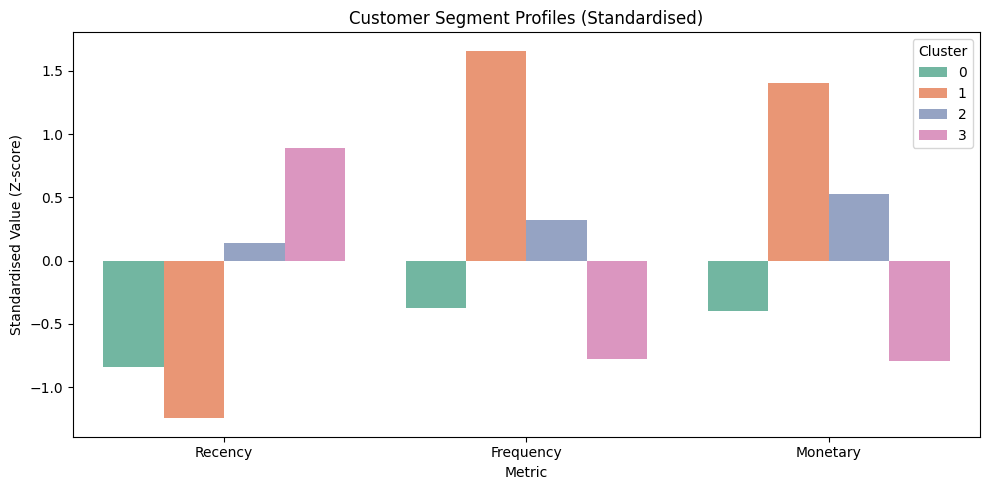

In [14]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

rfm_scaled_df['Cluster'] = rfm['Cluster'].values

cluster_profile = rfm_scaled_df.groupby('Cluster').mean().reset_index()

rfm_melt = cluster_profile.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(10, 5))
sns.barplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster', palette='Set2')
plt.title('Customer Segment Profiles (Standardised)')
plt.ylabel('Standardised Value (Z-score)')
plt.tight_layout()
plt.show()

### 10. Add Average Order Value (AOV) and Re-segment Customers

This section introduces a new metric, Average Order Value (AOV), and re-runs the clustering process to see if it provides different or more insightful customer segments:

-   **Calculate AOV:** A new column `AOV` is created in the `rfm` DataFrame by dividing `Monetary` by `Frequency`.
-   **Prepare Data with AOV:** The `Recency`, `Frequency`, `Monetary`, and `AOV` metrics are selected.
-   **Log Transformation and Scaling:** All four metrics are log-transformed (using `np.log1p`) and then standard-scaled to normalize their distributions and ranges.
-   **Re-run K-Means:** K-Means clustering is performed again with `k=4` on the new `rfm_scaled_aov` data, and the new cluster labels are added as `Cluster_AOV` to the `rfm` DataFrame.
-   **Profile New Segments:** The average `Recency`, `Frequency`, `Monetary`, and `AOV` are calculated for these new clusters, providing updated segment profiles.
-   **Visualize New Segments:** A new bar plot is generated, similar to the previous one, to visualize the standardized profiles of the customer segments including the AOV metric. This helps in comparing the impact of AOV on segment definition.


Average profile of new segments with AOV:
             Recency  Frequency  Monetary    AOV
Cluster_AOV                                     
0               20.4       13.1    8128.5  723.5
1              140.7        1.8     999.0  615.3
2               26.5        3.8     994.2  275.6
3              156.9        1.5     206.0  145.4


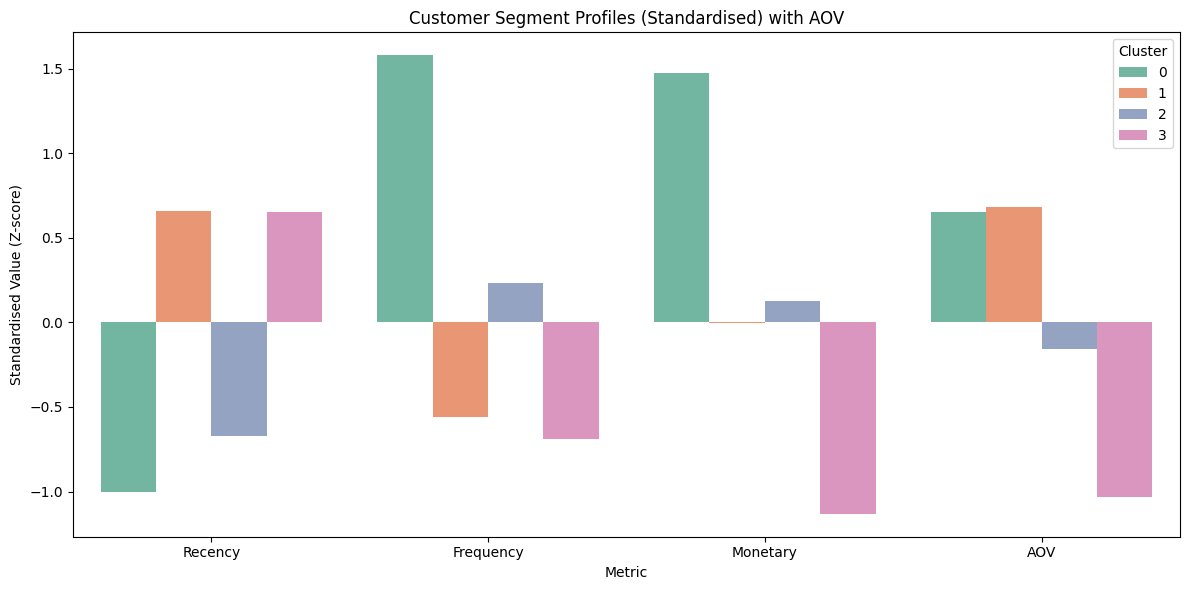

In [15]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']

# Prepare data for new segmentation with AOV
rfm_log_aov = rfm[['Recency', 'Frequency', 'Monetary', 'AOV']].copy()

# Apply log transformation
rfm_log_aov['Recency']   = np.log1p(rfm_log_aov['Recency'])
rfm_log_aov['Frequency'] = np.log1p(rfm_log_aov['Frequency'])
rfm_log_aov['Monetary']  = np.log1p(rfm_log_aov['Monetary'])
rfm_log_aov['AOV']       = np.log1p(rfm_log_aov['AOV'])

# Scale the data
scaler_aov = StandardScaler()
rfm_scaled_aov = scaler_aov.fit_transform(rfm_log_aov)

# Re-run K-Means with k=4 (based on previous elbow method, assuming it will still be suitable)
kmeans_aov = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster_AOV'] = kmeans_aov.fit_predict(rfm_scaled_aov)

rfm['Cluster_AOV'] = rfm['Cluster_AOV'].astype(str)

# Get the average profile of each new segment
summary_aov = rfm.groupby('Cluster_AOV')[['Recency', 'Frequency', 'Monetary', 'AOV']].mean().round(1)
print("\nAverage profile of new segments with AOV:")
print(summary_aov)

# Visualize new customer segment profiles with AOV
rfm_scaled_df_aov = pd.DataFrame(rfm_scaled_aov, columns=['Recency', 'Frequency', 'Monetary', 'AOV'])
rfm_scaled_df_aov['Cluster'] = rfm['Cluster_AOV'].values

cluster_profile_aov = rfm_scaled_df_aov.groupby('Cluster').mean().reset_index()

rfm_melt_aov = cluster_profile_aov.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=rfm_melt_aov, x='Metric', y='Value', hue='Cluster', palette='Set2')
plt.title('Customer Segment Profiles (Standardised) with AOV')
plt.ylabel('Standardised Value (Z-score)')
plt.tight_layout()
plt.show()

### Executive Summary: Enhancing Customer Engagement Through RFM and AOV Segmentation

This report presents a comprehensive customer segmentation analysis aimed at optimizing marketing strategies and maximizing customer lifetime value. Utilizing the robust RFM (Recency, Frequency, Monetary) framework, enhanced by the inclusion of Average Order Value (AOV), we have identified four distinct customer segments with unique behavioral patterns.

Our analysis revealed that incorporating AOV provided a more granular understanding of customer purchasing habits, distinguishing between frequent small-value buyers and infrequent large-value purchasers. This refined segmentation allows for more precise targeting and personalized engagement.

**Key Findings:**

*   **Champions (High-Value, High-Frequency, High AOV):** Our most valuable customers, characterized by recent, frequent, and high-spending behavior with significant average order values. This segment represents the core of our loyal customer base.
*   **Big Spenders (Infrequent but High AOV):** Customers who purchase less often but make substantial individual transactions. This segment offers an opportunity to increase purchase frequency.
*   **Regular Shoppers (Frequent but Low AOV):** Customers who shop frequently but tend to make smaller purchases. The strategic focus for this group is to increase their average order value.
*   **At-Risk/Lapsed Customers:** Customers with high recency (long time since last purchase), low frequency, low monetary value, and low AOV, indicating a high risk of churn or dormancy.

**Strategic Recommendations:**

By tailoring marketing efforts to each segment's specific needs and behaviors, we can significantly improve campaign effectiveness. Recommendations include implementing exclusive loyalty programs for Champions, triggering personalized offers for Big Spenders, cross-selling and upselling for Regular Shoppers, and targeted win-back campaigns for At-Risk/Lapsed customers.

This segmentation provides a clear, data-driven roadmap to foster stronger customer relationships, optimize marketing spend, and ultimately drive sustainable growth.

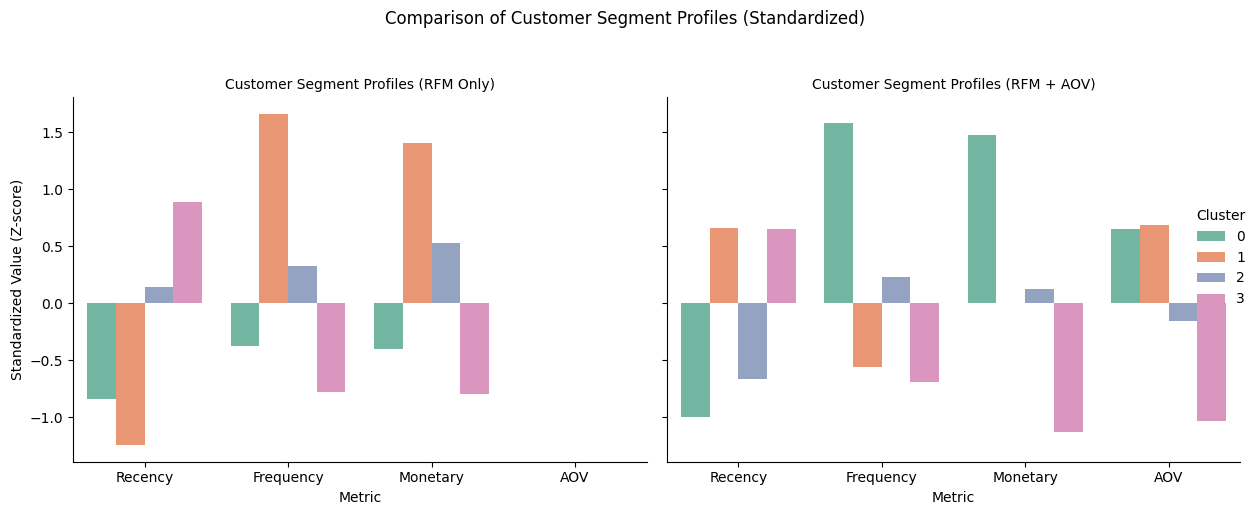

In [17]:
# Add a 'Segmentation' column to distinguish between the two segmentations
rfm_melt['Segmentation'] = 'RFM Only'
rfm_melt_aov['Segmentation'] = 'RFM + AOV'

# Combine the two melted DataFrames
combined_rfm_melt = pd.concat([rfm_melt, rfm_melt_aov])

# Create the visualization using FacetGrid or catplot
g = sns.catplot(
    data=combined_rfm_melt,
    x='Metric',
    y='Value',
    hue='Cluster',
    col='Segmentation', # Use 'Segmentation' to create two columns of plots
    kind='bar',
    palette='Set2',
    height=5,
    aspect=1.2,
    sharey=True # Share the y-axis scale for better comparison
)
g.set_axis_labels('Metric', 'Standardized Value (Z-score)')
g.set_titles('Customer Segment Profiles ({col_name})')
plt.suptitle('Comparison of Customer Segment Profiles (Standardized)', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [16]:
print(summary)

         Recency  Frequency  Monetary
Cluster                              
0           18.1        2.1     551.8
1           12.1       13.7    8074.3
2           71.1        4.1    1802.8
3          182.5        1.3     343.5
